In [22]:
# Standard imports
import numpy as np
import pandas as pd
import polars as pl
from pathlib import Path
import time

# Models
import lightgbm as lgb
import joblib

# Statistics
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.metrics import log_loss, roc_auc_score

import os
print(f"Current working directory: {os.getcwd()}")

# Paths - assume notebook is in notebooks/ directory
MODELS_DIR = Path("../models")
DATA_DIR = Path("../data/interim")

print(f"Models dir exists: {MODELS_DIR.exists()}")
print(f"Data dir exists: {DATA_DIR.exists()}")

Current working directory: C:\Users\jagod\Documents\GitHub\ctr-prediction\notebooks
Models dir exists: True
Data dir exists: True


## Loading models, encoders, and calibrator

In [4]:
# Load logistic regression model and its encoder
print("Loading logistic regression model...")
model_logreg = joblib.load(MODELS_DIR / "sgdclassifier_reg_log.pkl")
ohe = joblib.load(MODELS_DIR / "onehot_encoder.pkl")
print(f"  Model loaded: {type(model_logreg).__name__}")
print(f"  OHE loaded with {len(ohe.categories_)} categorical columns")

# Load LightGBM model, ordinal encoder, and isotonic calibrator
print("\nLoading LightGBM model...")
model_lgb = lgb.Booster(model_file=str(MODELS_DIR / "lightgbm_final.txt"))
ordinal_encoder = joblib.load(MODELS_DIR / "ordinal_encoder.pkl")
calibrator = joblib.load(MODELS_DIR / "isotonic_calibrator.pkl")
print(f"  Model loaded with {model_lgb.num_trees()} trees")
print(f"  Ordinal encoder loaded with {len(ordinal_encoder.categories_)} categories")
print(f"  Calibrator loaded: {type(calibrator).__name__}")

Loading logistic regression model...
  Model loaded: SGDClassifier
  OHE loaded with 23 categorical columns

Loading LightGBM model...
  Model loaded with 617 trees
  Ordinal encoder loaded with 21 categories
  Calibrator loaded: IsotonicRegression


In [7]:
from sklearn.feature_extraction import FeatureHasher

# Recreate the hasher - same parameters as previously
HASH_BUCKETS = {
    "device_id": 10000,
    "device_ip": 10000,
}

# Note: we'll create separate hashers for each column (same as before)
hashers = {}
for col, n_buckets in HASH_BUCKETS.items():
    hashers[col] = FeatureHasher(
        n_features=n_buckets,
        input_type="string",
        alternate_sign=False,
    )

print(f"Hashers created for: {list(hashers.keys())}")
print(f"Each with {HASH_BUCKETS['device_id']} buckets")

Hashers created for: ['device_id', 'device_ip']
Each with 10000 buckets


In [61]:
print(f"Logistic regression model expects: {model_logreg.coef_.shape[1]} features")

Logistic regression model expects: 51549 features


## Data preprocessing 

In [62]:
# Add time features and is_app flag
def add_features(df):
    return (
        df
        .with_columns(pl.col("hour").cast(pl.String).alias("hour_str"))
        .with_columns([
            pl.col("hour_str").str.slice(4, 2).cast(pl.Int8).alias("day"),
            pl.col("hour_str").str.slice(6, 2).cast(pl.Int8).alias("hour_of_day"),
        ])
        .with_columns(((pl.col("day") - 21 + 1) % 7).alias("day_of_week"))
        .with_columns(pl.col("day_of_week").is_in([5, 6]).alias("is_weekend"))
        .with_columns((pl.col("app_id") != "ecad2386").alias("is_app"))
        .drop(["hour_str", "id", "hour", "day"])
    )

# Load val
print("Loading val...")
val = add_features(pl.scan_parquet(DATA_DIR / "val_split.parquet")).collect()
print(f"Val shape: {val.shape}")

# Get y
y_val = val["click"].to_numpy()

X_val_raw = val.drop("click")

print(f"X_val_raw shape: {X_val_raw.shape}")
print(f"y_val shape: {y_val.shape}")

Loading val...
Val shape: (8051546, 26)
X_val_raw shape: (8051546, 25)
y_val shape: (8051546,)


In [11]:
# Convert polars to pandas for both pipelines
X_val_pd = X_val_raw.to_pandas()

print(f"X_val_pd shape: {X_val_pd.shape}")
print(f"X_val_pd columns: {list(X_val_pd.columns)}")
print(f"\nMemory: {X_val_pd.memory_usage(deep=True).sum() / 1e9 :.2f} GB")

X_val_pd shape: (8051546, 25)
X_val_pd columns: ['C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_app']

Memory: 4.97 GB


In [63]:
# OHE expects the order of categories (columns) to remain the same (copied from "03_feature_engineering")
ONEHOT_COLS = [
    # Low cardinality (<100 unique values)
    "C1","banner_pos","device_type","device_conn_type",
    "C15","C16","C18",
    "app_category","site_category",
    "hour_of_day","day_of_week",
    # Medium cardinality (100-10000 unique values)
    "C14", "C17","C19","C20","C21",
    "app_domain","app_id","site_domain","site_id","device_model",
    # Boolean feature (treat as categorical)
    "is_weekend", "is_app",
]

print(f"One-hot columns: {len(ONEHOT_COLS)}")
print(f"Hash columns: {list(HASH_BUCKETS.keys())}")

One-hot columns: 23
Hash columns: ['device_id', 'device_ip']


In [15]:
from scipy.sparse import hstack

print("Applying one-hot encoding to val...")
X_val_ohe = ohe.transform(X_val_pd[ONEHOT_COLS])

print(f"X_val_ohe shape: {X_val_ohe.shape}")
print(f"X_val_ohe type: {type(X_val_ohe).__name__}")

Applying one-hot encoding to val...


C:\Users\jagod\miniconda3\envs\ctr-prediction\Lib\site-packages\sklearn\preprocessing\_encoders.py:241: UserWarning: Found unknown categories in columns [11, 12, 13, 15, 16, 17, 18, 19, 20] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


X_val_ohe shape: (8051546, 31549)
X_val_ohe type: csr_matrix


In [74]:
print("Applying feature hashing to val...")

hashed_parts = []

for col, hasher in hashers.items():
    # Get column values as list of strings
    values = X_val_pd[col].astype(str).tolist()
    # Hasher needs each row as a list of tokens - each row is one token (one device_id value)
    tokens_per_row = []
    for value in values:
        tokens_per_row.append([value])
    # Apply hashing
    hashed = hasher.transform(tokens_per_row)
    hashed_parts.append(hashed)
    print(f"  {col}: shape {hashed.shape}")
    
# Combine all hashed columns horizontally
X_val_hashed = hstack(hashed_parts).tocsr()
print(f"\nCombined X_val_hashed shape: {X_val_hashed.shape}")

Applying feature hashing to val...
  device_id: shape (8051546, 10000)
  device_ip: shape (8051546, 10000)

Combined X_val_hashed shape: (8051546, 20000)


In [75]:
print("Combining one-hot and hashed features for logistic regression...")

X_val_logreg = hstack([X_val_ohe, X_val_hashed]).tocsr()

print(f"X_val_logreg shape: {X_val_logreg.shape}")
print(f"Expected by model:  ({model_logreg.coef_.shape[1]},)")

# Sanity check
if X_val_logreg.shape[1] == model_logreg.coef_.shape[1]:
    print("Dimensions match, ready for prediction.")
else:
    print(f"Dimension mismatch!")
    print(f"  X_val_logreg has {X_val_logreg.shape[1]} columns")
    print(f"  model_logreg expects {model_logreg.coef_.shape[1]} features")

Combining one-hot and hashed features for logistic regression...
X_val_logreg shape: (8051546, 51549)
Expected by model:  (51549,)
Dimensions match, ready for prediction.


In [76]:
# LightGBM doesn't handle device_id/device_ip well (due to mega-cardinality)
# --> drop them and use ordinal encoding on remaining categorical columns

CATEGORICAL_COLS_LGB = [
    "C1", "banner_pos", "device_type", "device_conn_type",
    "C14", "C15", "C16", "C17", "C18", "C19", "C20", "C21",
    "hour_of_day", "day_of_week",
    "site_id", "site_domain", "site_category",
    "app_id", "app_domain", "app_category",
    "device_model",
]

# Create separate copy for LightGBM pipeline
X_val_lgb = X_val_pd.drop(columns=["device_id", "device_ip"]).copy()

# Apply ordinal encoder
X_val_lgb[CATEGORICAL_COLS_LGB] = ordinal_encoder.transform(X_val_lgb[CATEGORICAL_COLS_LGB])

# Convert boolean columns to int8
X_val_lgb["is_weekend"] = X_val_lgb["is_weekend"].astype("int8")
X_val_lgb["is_app"] = X_val_lgb["is_app"].astype("int8")

print(f"X_val_lgb shape: {X_val_lgb.shape}")
print(f"Expected by model: {model_lgb.num_feature()} features")

# Sanity check
if X_val_lgb.shape[1] == model_lgb.num_feature():
    print("Dimensions match, ready for prediction.")
else:
    print(f"Dimension mismatch!")
    print(f"  X_val_lgb has {X_val_lgb.shape[1]} columns")
    print(f"  model_lgb expects {model_lgb.num_feature()} features")

X_val_lgb shape: (8051546, 23)
Expected by model: 23 features
Dimensions match, ready for prediction.


# Predictions from both models

In [66]:
# Logistic regression - predict_proba
print("Generating logistic regression predictions...")

start = time.time()
y_pred_logreg = model_logreg.predict_proba(X_val_logreg)[:, 1]
print(f"  Time: {time.time() - start:.1f}s")
print(f"  Range: [{y_pred_logreg.min():.4f}, {y_pred_logreg.max():.4f}]")
print(f"  Mean:  {y_pred_logreg.mean():.4f}")

# LightGBM - raw prediction, then calibrate
print("\nGenerating LightGBM predictions...")
start = time.time()
y_pred_lgb_raw = model_lgb.predict(X_val_lgb.values)
print(f"  Time: {time.time() - start:.1f}s")

# Apply isotonic calibrator
y_pred_lgb_cal = calibrator.transform(y_pred_lgb_raw) 

print(f"\n  Raw range:        [{y_pred_lgb_raw.min():.4f}, {y_pred_lgb_raw.max():.4f}]")
print(f"  Raw mean:         {y_pred_lgb_raw.mean():.4f}")
print(f"  Calibrated range: [{y_pred_lgb_cal.min():.4f}, {y_pred_lgb_cal.max():.4f}]")
print(f"  Calibrated mean:  {y_pred_lgb_cal.mean():.4f}")
print(f"\nActual CTR (val): {y_val.mean():.4f}")

Generating logistic regression predictions...
  Time: 1.5s
  Range: [0.0078, 0.8184]
  Mean:  0.1712

Generating LightGBM predictions...
  Time: 66.8s

  Raw range:        [0.0000, 0.9868]
  Raw mean:         0.1675
  Calibrated range: [0.0000, 1.0000]
  Calibrated mean:  0.1631

Actual CTR (val): 0.1632


Half of the val set was used for the calibration of LightGBM model. In the following A/B tests only the "unseen" part of the val set will be used.

##### __LightGBM needed ~10x more time to generate predictions!__

# Comparing LightGBM and Logistic Regression

In [25]:
# Recreate the same split as in calibration
np.random.seed(42) # same seed ensures the same split
n = len(y_val)
indices = np.random.permutation(n)
split_point = n // 2

# new_val was the second half (unbiased data for A/B test)
new_val_indices = indices[split_point:]

# Subset all predictions
y_val_test = y_val[new_val_indices]
y_pred_logreg_test = y_pred_logreg[new_val_indices]
y_pred_lgb_test = y_pred_lgb_cal[new_val_indices]

print(f"Test set size: {len(y_val_test):,} rows")
print(f"Test CTR: {y_val_test.mean():.4f}")
print(f"\nLogistic regression mean prediction: {y_pred_logreg_test.mean():.4f}")
print(f"LightGBM (calibrated) mean prediction: {y_pred_lgb_test.mean():.4f}")

Test set size: 4,025,773 rows
Test CTR: 0.1634

Logistic regression mean prediction: 0.1712
LightGBM (calibrated) mean prediction: 0.1631


## Top-K analysis

In [67]:
# Sort predictions and calculate the click rate at different thresholds
def click_rate_at_top_k(y_true, y_pred, top_k_fraction):
    """
    Calculate actual click rate among top K fraction of predictions.
    
    Arguments:
        y_true: actual click labels (0 or 1)
        y_pred: predicted probabilities
        top_k_fraction: e.g., 0.1 for top 10%
    
    Returns:
        click_rate in a selected group
    """
    n = len(y_true)
    n_top = int(n * top_k_fraction)
    
    # Get indices of top K predictions
    top_indices = np.argsort(y_pred)[-n_top:] # last n_top of sorted elements = the biggest values
    
    # Compute click rate in this group
    return y_true[top_indices].mean()

In [27]:
# Test for different top K fractions
fractions = [0.01, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00]

print("Click rate at top K%:")
print(f"{'Top K':<10} {'Logistic':<12} {'LightGBM':<12} {'Lift':<10}")
print("-" * 45)

for frac in fractions:
    cr_logreg = click_rate_at_top_k(y_val_test, y_pred_logreg_test, frac)
    cr_lgb = click_rate_at_top_k(y_val_test, y_pred_lgb_test, frac)
    lift = (cr_lgb - cr_logreg) / cr_logreg * 100
    print(f"{frac*100:>4.0f}%      {cr_logreg:.4f}      {cr_lgb:.4f}      {lift:+.2f}%")

Click rate at top K%:
Top K      Logistic     LightGBM     Lift      
---------------------------------------------
   1%      0.6368      0.6884      +8.11%
   5%      0.4650      0.4968      +6.82%
  10%      0.3960      0.4216      +6.47%
  20%      0.3431      0.3550      +3.47%
  30%      0.3096      0.3177      +2.63%
  50%      0.2573      0.2611      +1.46%
 100%      0.1634      0.1634      +0.00%


#### Interpretation:
- higher LightGBM click-rates compared to logistic regression (lift > 0)
- higher K --> lower difference between the models
- a few p.p. difference at the most important 1% of ad views may be a big distinction from the business point of few

Are these differences statistically important? Next, only top 5% will be analyzed.

## Hypotheses:
- Hipothesis 0. - click rate is the same for both models
- Hipothesis 1. - click rate is different for both models

In [69]:
from scipy.stats import norm

# Top 5% threshold
top_k_frac = 0.05
n = len(y_val_test)
n_top = int(n * top_k_frac)

# Get top K indices for each model
top_logreg = np.argsort(y_pred_logreg_test)[-n_top:]
top_lgb = np.argsort(y_pred_lgb_test)[-n_top:]

# Counts of clicks in each top K group
clicks_logreg = y_val_test[top_logreg].sum()
clicks_lgb = y_val_test[top_lgb].sum()

# Click rates (average for the chosen K)
p_logreg = clicks_logreg / n_top
p_lgb = clicks_lgb / n_top

# Pooled proportion (assumed H0 - no difference)
p_pool = (clicks_logreg + clicks_lgb) / (2 * n_top)

# Standard error under H0
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_top + 1/n_top))

# Z-statistic
z = (p_lgb - p_logreg) / se

# Two-sided p-value
p_value = 2 * (1 - norm.cdf(abs(z)))

print(f"Top {top_k_frac*100:.0f}% comparison:\n")
print(f"  N in each group:     {n_top:,}")
print(f"  Logistic clicks:     {clicks_logreg:,} (rate: {p_logreg:.4f})")
print(f"  LightGBM clicks:     {clicks_lgb:,} (rate: {p_lgb:.4f})")
print(f"  Difference:          {p_lgb - p_logreg:+.4f}")
print(f"  Z-statistic:         {z:.4f}")
print(f"  P-value:             {p_value:.8f}")
print(f"  Significant at 0.05? {'YES' if p_value < 0.05 else 'NO'}")

Top 5% comparison:

  N in each group:     201,288
  Logistic clicks:     93,606 (rate: 0.4650)
  LightGBM clicks:     99,991 (rate: 0.4968)
  Difference:          +0.0317
  Z-statistic:         20.1411
  P-value:             0.00000000
  Significant at 0.05? YES


- P-value virtually 0 --> the models are definitely not equivalent
- Z-statistic ~20 - extreme --> the difference is 20 standard errors (SE) away from 0
- __hipothesis 1. proven --> hipothesis 0. rejected__

#### The difference statistically certain - but is it practically relevant? 
- the difference in clicks suggests it is: 93,606 vs 99,991 = 6385 clicks (~7% more clicks for LightGBM)

### Confidence interval

In [39]:
# 97.5% quantile
z_975 = norm.ppf(0.975) # ppf - percent point function
print(f"z for 97.5% quantile: {z_975:.3f}")

z for 97.5% quantile: 1.960


In [70]:
# 95% confidence interval (CI) for the difference in click rates
# Using normal approximation for difference of proportions

# Standard error WITHOUT pooling (for CI - observed proportions used)
se_diff = np.sqrt(p_logreg * ((1 - p_logreg) / n_top) + (p_lgb * (1 - p_lgb) / n_top))

# 95% CI = difference +- 1.96 * SE (97.5% = (1 + 0.95)*100% / 2 --> 1.96)
diff = p_lgb - p_logreg
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print(f"Difference in click rate: {diff:.4f} ({diff*100:.2f} percentage points)")
print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"In percentage points:    [{ci_lower*100:.2f}, {ci_upper*100:.2f}] p.p.")
print(f"\nRelative lift: {(p_lgb - p_logreg) / p_logreg * 100:.2f}%")

# Confidence interval for relative lift
relative_lift = (p_lgb - p_logreg) / p_logreg
relative_lift_lower = ci_lower / p_logreg
relative_lift_upper = ci_upper / p_logreg
print(f"95% CI for relative lift: [{relative_lift_lower*100:.2f}%, {relative_lift_upper*100:.2f}%]")

Difference in click rate: 0.0317 (3.17 percentage points)
95% Confidence Interval: [0.0286, 0.0348]
In percentage points:    [2.86, 3.48] p.p.

Relative lift: 6.82%
95% CI for relative lift: [6.16%, 7.48%]


- LightGBM is better by 2.86-3.48 p.p. with high confidence (95%)
- the difference is not 0 (0 is not in the range [0.0286, 0.0348])

## Effect size - Cohen's h
- proportions are not linear in the importance scale - calculating differences directly doesn't make sense
- arcsine transformation extends the scale of proportions --> the differences become comparable
- the difference between the transformed proportions = Cohen's h

In [77]:
# Cohen's h - effect size for the difference of proportions
def cohens_h(p1, p2):
    """
    Cohen's h - standardized effect size for difference of proportions.
    
    Interpretation guide:
    - 0.2: small effect
    - 0.5: medium effect
    - 0.8: large effect
    """
    phi1 = 2 * np.arcsin(np.sqrt(p1))
    phi2 = 2 * np.arcsin(np.sqrt(p2))
    return phi1 - phi2

h = cohens_h(p_lgb, p_logreg)
print(f"Cohen's h: {h:.4f}")

if abs(h) < 0.2:
    interpretation = "small effect"
elif abs(h) < 0.5:
    interpretation = "medium effect"
else:
    interpretation = "large effect"
print(f"Interpretation: {interpretation}")

Cohen's h: 0.0635
Interpretation: small effect


- small difference in absolute scale (small statistically but may be important from the business point of view)

### Statistical power analysis

In [47]:
def required_sample_size(p1, p2, alpha=0.05, power=0.80):
    """
    Calculate sample size needed per group to detect difference between two proportions.
    
    Arguments:
        p1, p2: proportions in two groups
        alpha: significance level (default 0.05)
        power: desired power (default 0.80 --> 80% chance to detect real effect)
    """
    z_alpha = norm.ppf(1 - alpha / 2) # 1.96 for alpha=0.05
    z_beta = norm.ppf(power) # 0.84 for power=0.80
    
    p_avg = (p1 + p2) / 2
    
    # Sample size formula for two proportions
    n = ((z_alpha * np.sqrt(2 * p_avg * (1 - p_avg)) + 
          z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2 / 
         (p1 - p2) ** 2)
    
    return int(np.ceil(n))


# How much data did we need?
needed = required_sample_size(p_logreg, p_lgb)
print(f"Required sample size per group: {needed:,}")
print(f"Actual sample size per group: {n_top:,}")
print(f"Ratio (actual/needed): {n_top / needed:.1f}x")

# How small effect could we detect?
print(f"\nEven smaller effects could be detected with this sample size.")

Required sample size per group: 3,894
Actual sample size per group: 201,288
Ratio (actual/needed): 51.7x

Even smaller effects could be detected with this sample size.


### Minimum detectable effect

In [71]:
def minimum_detectable_effect(n_per_group, p_baseline, alpha=0.05, power=0.80):
    """
    What's the smallest effect that can be detected given the sample size?
    
    Returns:
        Minimum detectable difference in proportions
    """
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    
    # Approximate MDE assuming p1 close to p2
    se = np.sqrt(2 * p_baseline * (1 - p_baseline) / n_per_group)
    mde = (z_alpha + z_beta) * se
    
    return mde


mde = minimum_detectable_effect(n_top, p_logreg)
mde_relative = mde / p_logreg * 100

print(f"Sample size per group:              {n_top:,}")
print(f"Baseline click rate:                {p_logreg:.4f}")
print(f"Minimum detectable absolute effect: {mde:.4f} ({mde*100:.2f} p.p.)")
print(f"Minimum detectable relative effect: {mde_relative:.2f}%")

print(f"\nObserved effect:      {p_lgb - p_logreg:.4f} ({(p_lgb - p_logreg)*100:.2f} p.p.)")
print(f"Observed relative lift: {(p_lgb - p_logreg)/p_logreg*100:.2f}%")

Sample size per group:              201,288
Baseline click rate:                0.4650
Minimum detectable absolute effect: 0.0044 (0.44 p.p.)
Minimum detectable relative effect: 0.95%

Observed effect:      0.0317 (3.17 p.p.)
Observed relative lift: 6.82%


- we had ~52x more data than it was needed to detect the difference between the models

### Lift curve

Relative lift - first 5 values (%): [8.10578873 8.26672412 7.1210163  6.93967538 6.82114394]
Max lift: 8.27%
Min lift: 0.00%


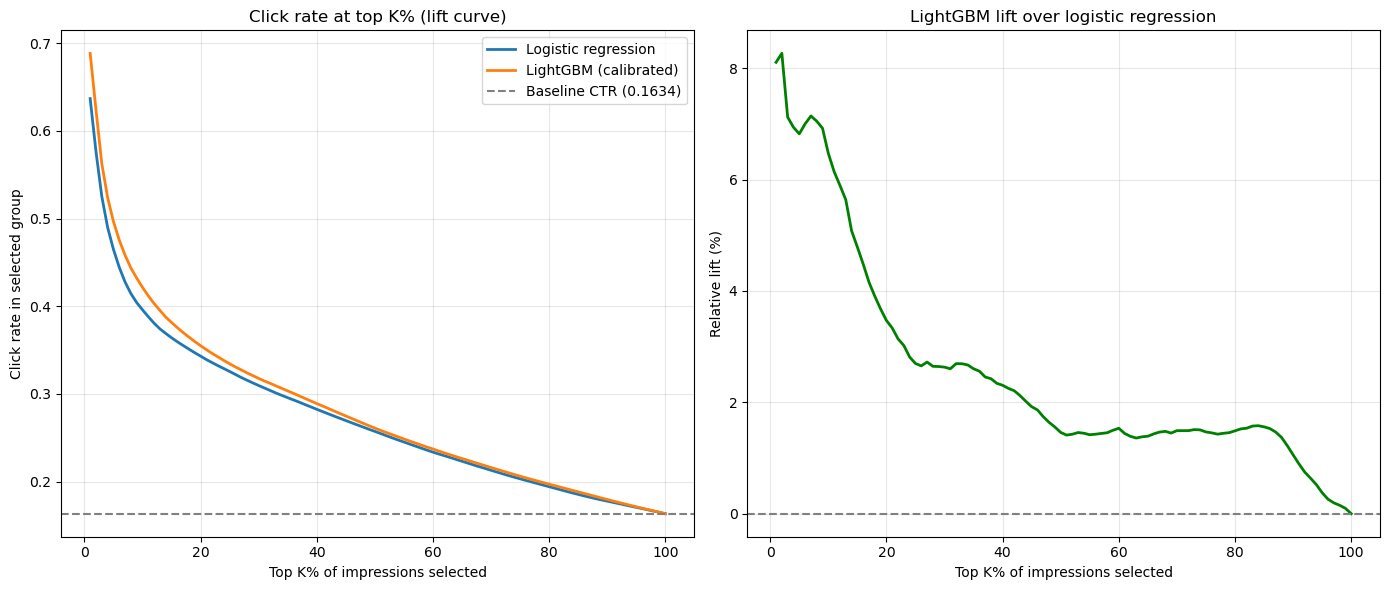

In [53]:
# More granular fractions for smooth curve
fractions = np.arange(0.01, 1.01, 0.01)

cr_logreg_curve = []
cr_lgb_curve = []

# For each fraction, compute click rate for both models
for frac in fractions:
    # Click rate for logistic regression at this top K%
    rate_logreg = click_rate_at_top_k(y_val_test, y_pred_logreg_test, frac)
    # Click rate for LightGBM at this top K%
    rate_lgb = click_rate_at_top_k(y_val_test, y_pred_lgb_test, frac)
    # Add results to the lists
    cr_logreg_curve.append(rate_logreg)
    cr_lgb_curve.append(rate_lgb)

# Convert lists to numpy arrays for math operations
cr_logreg_curve = np.array(cr_logreg_curve)
cr_lgb_curve = np.array(cr_lgb_curve)

# Plot lift curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: absolute click rate at top K%
axes[0].plot(fractions * 100, cr_logreg_curve, label="Logistic regression", linewidth=2)
axes[0].plot(fractions * 100, cr_lgb_curve, label="LightGBM (calibrated)", linewidth=2)
axes[0].axhline(y=y_val_test.mean(), color="gray", linestyle="--", label=f"Baseline CTR ({y_val_test.mean():.4f})")
axes[0].set_xlabel("Top K% of impressions selected")
axes[0].set_ylabel("Click rate in selected group")
axes[0].set_title("Click rate at top K% (lift curve)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: relative lift

# Relative lift = how much better is LightGBM compared to logistic regression
# (LightGBM rate - logreg rate) / logreg rate
relative_lift = (cr_lgb_curve - cr_logreg_curve) / cr_logreg_curve * 100
print(f"Relative lift - first 5 values (%): {relative_lift[:5]}")
print(f"Max lift: {relative_lift.max():.2f}%")
print(f"Min lift: {relative_lift.min():.2f}%")
axes[1].plot(fractions * 100, relative_lift, color="green", linewidth=2)
axes[1].axhline(y=0, color="gray", linestyle="--")
axes[1].set_xlabel("Top K% of impressions selected")
axes[1].set_ylabel("Relative lift (%)")
axes[1].set_title("LightGBM lift over logistic regression")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary

In [73]:
# Additional metrics for the comparison
log_loss_logreg = log_loss(y_val_test, y_pred_logreg_test)
log_loss_lgb = log_loss(y_val_test, y_pred_lgb_test)

auc_logreg = roc_auc_score(y_val_test, y_pred_logreg_test)
auc_lgb = roc_auc_score(y_val_test, y_pred_lgb_test)

# Summary table
print(f"{'A/B TEST RESULTS - LightGBM vs Logistic Regression':^60}")

print(f"\nTest set size: {len(y_val_test):,} rows")
print(f"Test set CTR: {y_val_test.mean():.4f}")

print(f"\n{'Metric':<25} {'Logistic':<15} {'LightGBM':<15}")

print(f"{'Log loss':<25} {log_loss_logreg:<15.4f} {log_loss_lgb:<15.4f}")
print(f"{'AUC':<25} {auc_logreg:<15.4f} {auc_lgb:<15.4f}")
print(f"{'Click rate at top 5%':<25} {p_logreg:<15.4f} {p_lgb:<15.4f}")
print(f"{'Mean prediction':<25} {y_pred_logreg_test.mean():<15.4f} {y_pred_lgb_test.mean():<15.4f}")

print(f"\n\n{'BUSINESS METRICS (top 5% threshold)':^55}\n")

print(f"Absolute lift (LightGBM vs LogReg):     {(p_lgb - p_logreg)*100:.2f} p.p.")
print(f"Relative lift (LightGBM vs LogReg):     {(p_lgb - p_logreg)/p_logreg*100:.2f}%")
print(f"Additional clicks (LightGBM vs LogReg): {int(clicks_lgb - clicks_logreg):,}")
print(f"95% CI for relative lift:               [{(ci_lower/p_logreg)*100:.2f}%, {(ci_upper/p_logreg)*100:.2f}%]")

print(f"\n\n{'STATISTICAL TESTS (top 5% threshold)':^55}\n")

print(f"Z-statistic:             {z:.2f}")
print(f"P-value:                 {p_value:.2e}")
print(f"Cohen's h (effect size): {h:.4f} ({interpretation})")
print(f"Statistically significant at 0.05? {'YES' if p_value < 0.05 else 'NO'}")

print(f"\n\n{'POWER ANALYSIS (top 5% threshold)':^55}\n")

print(f"Required sample size per group: {needed:,}")
print(f"Actual sample size per group:   {n_top:,}")
print(f"Excess data ratio:              {n_top / needed:.1f}x")
print(f"Minimum detectable effect:      {mde*100:.3f} p.p. ({mde_relative:.2f}% relative)")

     A/B TEST RESULTS - LightGBM vs Logistic Regression     

Test set size: 4,025,773 rows
Test set CTR: 0.1634

Metric                    Logistic        LightGBM       
Log loss                  0.3974          0.3887         
AUC                       0.7318          0.7469         
Click rate at top 5%      0.4650          0.4968         
Mean prediction           0.1712          0.1631         


          BUSINESS METRICS (top 5% threshold)          

Absolute lift (LightGBM vs LogReg):     3.17 p.p.
Relative lift (LightGBM vs LogReg):     6.82%
Additional clicks (LightGBM vs LogReg): 6,385
95% CI for relative lift:               [6.16%, 7.48%]


         STATISTICAL TESTS (top 5% threshold)          

Z-statistic:             20.14
P-value:                 0.00e+00
Cohen's h (effect size): 0.0635 (small effect)
Statistically significant at 0.05? YES


           POWER ANALYSIS (top 5% threshold)           

Required sample size per group: 3,894
Actual sample size per group:   2

# A/B Test Conclusions

## Recommendation: Deploy LightGBM (calibrated) to production

The new model (LightGBM with isotonic calibration) significantly outperforms 
the previous model (logistic regression with feature hashing).

## Key findings

### Statistical significance
- Z-statistic: 20.14, p-value < 10^-80
- Sample size 51.7x larger than required for 80% power
- The result is certain beyond reasonable doubt

### Business impact (LightGBM vs Logistic Regression)
- +6.82% relative lift in click rate at top 5% threshold
- +6385 additional clicks in the test set (4M rows)
- 95% confidence interval for lift in [6.16%, 7.48%] range

### Model quality (LightGBM vs Logistic Regression)
- AUC improvement: 0.7318 --> 0.7469
- Log loss improvement: 0.3974 --> 0.3887
- Mean prediction matches actual CTR

## Considerations

### Inference latency
LightGBM prediction is ~100x slower than logistic regression (65 s vs 0.6 s for 8M predictions). For real-time bidding this difference may matter. 

Consider:
- Latency budget allowed by the RTB system
- Model size on disk (LightGBM 20 MB vs logreg 0.4 MB)

### Effect size context
While Cohen's h shows "small effect", in RTB context where billions of auctions happen daily, +6.82% lift may correspond to a substantial revenue. Interpretation requires considering the effect size in context.

### Test simulation limitations
This A/B test is a simulation on historical data (October 2014), not a real production A/B test. 

In production:
- New model could have different behavior on actual auction dynamics
- Bidding patterns from competitors might shift
- Deploy to small % of traffic first, monitor the metrics